In [2]:
from matplotlib import category

import Predictor
import matplotlib.pyplot as plt
import pandas as pd
unprocessedData = Predictor.predict(filePath="C:\\Users\\sophi\\Downloads\\activity (4).xlsx")
DescriptorValues = pd.Categorical(unprocessedData["Description"]).as_ordered()
processedData, thresholds, AmountClassifiers, CategoryClassifiers, DescriptionClassifiers = Predictor.ConvertToValues(unprocessedData)

ValueError: The number of FixedLocator locations (23), usually from a call to set_ticks, does not match the number of labels (16).

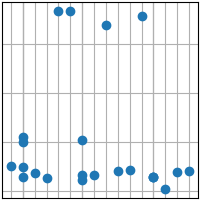

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


plt.style.use('_mpl-gallery')

# plot:
fig, ax = plt.subplots()
ax.set_title('Description Value vs Amount in USD')
ax.axes.set_xlabel('Description')
ax.set_ylabel('Amount in USD')

# Factorized values - array value denotes index of obj, value can be fed to index to get the category
# vals vars are X by 1, Labels vars are <variableCount> by 1
xVals, xLabels = unprocessedData['Description'].factorize() # where the purchase was made
yVals, yLabels = unprocessedData['Amount'].factorize() # how much it cost
zVals, zLabels = unprocessedData['Category'].factorize()# Correlates to which category the purchase should be in

data = {
    'xVals' : xVals,
    'yVals' : yVals,
    'zVals' : zVals
}

combinedArray = pd.DataFrame(data)

plot = ax.scatter(combinedArray['xVals'], yLabels.take(yVals))

shortDescs = pd.Categorical(xLabels)
shortDescs = shortDescs.categories.str.slice(0,5)
ax.set_xticks(combinedArray['xVals'], labels=shortDescs.take(xVals)) # x ticks are short description values
ax.set_yticks(range(0, yLabels.astype(int).max(), 10)) # y ticks are in dollars

for label in ax.get_xticklabels():
    label.set_fontsize('xx-small')
    label.set_multialignment('right')
    label.set_rotation(20)

fig.set_size_inches(8, 6)
fig.set_constrained_layout(True)
fig.set_constrained_layout_pads(w_pad=0.5, h_pad=0.5, hspace=0.5, wspace=0.5)


plt.show()
       